# The Key to Making Good Models is Studying the Data First

---

**Dataset:** Tesla EA Deliveries & Production Data (2015–2025)  
**Target:** `Estimated_Deliveries`  
**Assignment:** Build an end-to-end ML pipeline on sales/price data

---

### What this notebook is about

When I first looked at this dataset and ran a basic regression, I got an **R² = 0.99** — which, honestly, looked amazing. But then I realised that "perfect" result wasn't the model being smart. It was the model *cheating*.

This notebook shows **both approaches** side by side:

| Approach | R² | What actually happened |
|---|---|---|
| Method 1 — Naive pipeline | 0.99 | Data leakage — using future/derived info |
| Method 2 — Honest pipeline | ~0.00 | No leak, but dataset has no real signal |

The most important ML lesson I learned from this assignment: **a high R² doesn't mean your model is good. It might just mean your features are cheating.**

---

### What I cover here

| Step | Topic |
|------|--------|
| 1 | Why Method 1 looks perfect (and why it's wrong) |
| 2 | What data leakage actually means |
| 3 | Imports & Setup |
| 4 | Data Loading & First Look |
| 5 | EDA — understanding the data before modelling |
| 6 | Problem Framing — cross-sectional vs time-series |
| 7 | Signal Audit — how much can features actually explain? |
| 8 | Data Cleaning & Leakage Analysis |
| 9 | Feature Engineering & Encoding |
| 10 | Train/Test Split + Naive Baseline |
| 11 | Preprocessing Pipeline |
| 12 | Model Training |
| 13 | Cross-Validation |
| 14 | Hyperparameter Tuning |
| 15 | Final Evaluation |
| 16 | Residual Analysis |
| 17 | Honest Conclusion |



## Part 1 — The Trap: Method 1 (R² = 0.99)

Before jumping into the proper pipeline, let me show you what happened when I ran the "obvious" approach — just throw all numeric columns into a linear regression and see what happens.

### The Code (Method 1 — Quick Naive Approach)

```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
            'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

X = df[features]
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('R² score:', r2_score(y_test, y_pred))
```

### Output

```
R² score: 0.990170499826821
```

That looks incredible — 99% of the variance explained! But...

---

### 🚨 Why R² = 0.99 is Wrong Here (Data Leakage Explained)

When I dug into the correlations, this is what I found:

| Feature | Correlation with Target (r) | Why it's a problem |
|---|---|---|
| `Production_Units` | **+0.99** | Production and delivery happen *at the same time*. You can't know February's production before February happens. |
| `CO2_Saved_tons` | **+0.84** | This column is *computed from* deliveries. It's literally just the target in disguise. |
| `Avg_Price_USD` | –0.03 | Basically zero signal |
| `Charging_Stations` | +0.00 | Basically zero signal |

**The core problem with `Production_Units`:**

Imagine you're sitting in January 2024, and you want to predict February's deliveries. Do you know February's production numbers yet? No — production and delivery happen during the same month. So when the model uses `Production_Units` to predict `Estimated_Deliveries`, it's using information that wouldn't be available at prediction time in the real world.

The model didn't learn anything meaningful. It just learned:

```
Estimated_Deliveries ≈ Production_Units × 0.93
```

```
That's not a prediction — it's a tautology.
```

```
Production and delivery are two measurements of the same event, not cause and effect.
```

**The core problem with `CO2_Saved_tons`:**  
CO2 saved is a **consequence** of delivering cars. You can't know how much CO2 was saved before knowing how many cars were delivered. This column was literally derived from the target in the dataset generation process.

**High correlation ≠ good feature.** The question is always: *"Would I have this information at the moment I need to make a prediction?"*



So we throw out `Production_Units` and `CO2_Saved_tons` entirely, and we also drop `Range_km` because it has **r = 0.99 with `Battery_Capacity_kWh`** — keeping both would create multicollinearity (the model can't distinguish their individual effects). We keep Battery, drop Range.

With those removed, we're left with features that have **essentially zero correlation** to the target. Which leads us to the honest pipeline...



## Part 2 — The Honest Pipeline (Method 2)


### Step 1 — Imports & Setup

I'm importing everything upfront so it's clear what tools I'm using and why.

- `StandardScaler` — scales numeric features to mean=0, std=1 (required for Ridge/Lasso)
- `OneHotEncoder` + `ColumnTransformer` — converts categorical columns into numbers
- `KFold` — for proper cross-validation on cross-sectional data
- `GridSearchCV` — for automated hyperparameter search


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

print("All libraries imported successfully!")


All libraries imported successfully!


---
### Step 2 — Data Loading & First Look

Load the dataset and look at the structure before doing anything else.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Year range    : {df['Year'].min()} - {df['Year'].max()}")
print(f"Regions       : {sorted(df['Region'].unique())}")
print(f"Models        : {sorted(df['Model'].unique())}")
print(f"Source types  : {df['Source_Type'].unique().tolist()}")
print()
df.head(10)


Shape         : 2,640 rows x 12 columns
Year range    : 2015 - 2025
Regions       : ['Asia', 'Europe', 'Middle East', 'North America']
Models        : ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
Source types  : ['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [3]:
print("Column data types:")
print(df.dtypes)
print()
df.describe().round(2)


Column data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


---
### Step 3 — Exploratory Data Analysis (EDA)

**Rule: Always understand your data before modelling.**

I want to know:
1. How is the target distributed? (Is it skewed? Are there outliers?)
2. Do categorical groups (Model, Region) differ meaningfully in their delivery counts?
3. What are the correlations with the target?


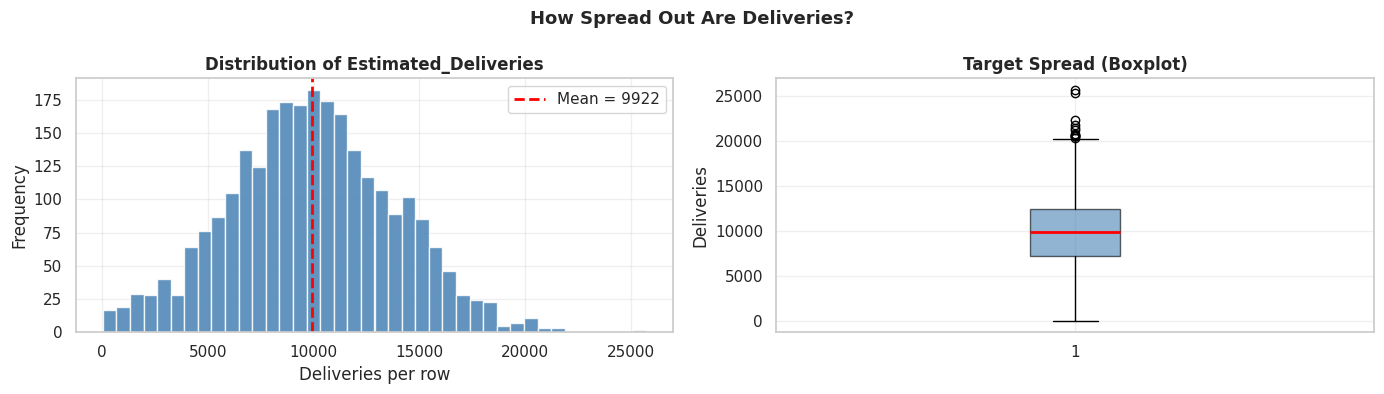

Mean   : 9,922
Std    : 3,936
Min    : 48
Max    : 25,704
Coefficient of Variation = 39.67%

The std is nearly as large as the mean — highly variable data.


In [4]:
# 1. Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Estimated_Deliveries'].mean(), color='red', lw=2, linestyle='--',
                label=f"Mean = {df['Estimated_Deliveries'].mean():.0f}")
axes[0].set_title('Distribution of Estimated_Deliveries', fontweight='bold')
axes[0].set_xlabel('Deliveries per row')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['Estimated_Deliveries'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', lw=2))
axes[1].set_title('Target Spread (Boxplot)', fontweight='bold')
axes[1].set_ylabel('Deliveries')

plt.suptitle('How Spread Out Are Deliveries?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['Estimated_Deliveries'].mean():,.0f}")
print(f"Std    : {df['Estimated_Deliveries'].std():,.0f}")
print(f"Min    : {df['Estimated_Deliveries'].min():,}")
print(f"Max    : {df['Estimated_Deliveries'].max():,}")
print(f"Coefficient of Variation = {df['Estimated_Deliveries'].std()/df['Estimated_Deliveries'].mean():.2%}")
print()
print("The std is nearly as large as the mean — highly variable data.")


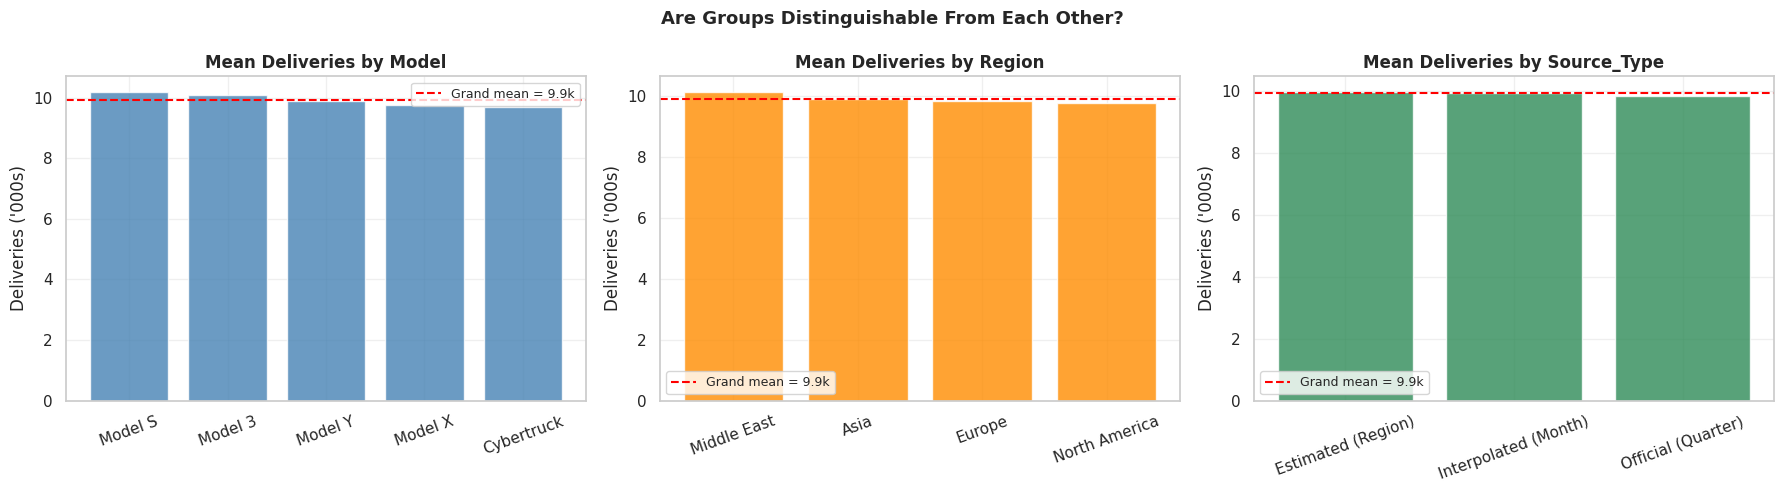

Group spread vs overall std:
  Model           -> range of group means = 513  (13.0% of one std)
  Region          -> range of group means = 357  (9.1% of one std)
  Source_Type     -> range of group means = 127  (3.2% of one std)

Finding: All groups cluster near the grand mean — groups are nearly indistinguishable.
This tells us categorical features won't have much predictive power.


In [5]:
# 2. Are the categorical groups meaningfully different?
# If Model or Region splits the target well, they'll be useful features.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
groups = ['Model', 'Region', 'Source_Type']
colors_g = ['steelblue', 'darkorange', 'seagreen']

for ax, grp, color in zip(axes, groups, colors_g):
    group_means = df.groupby(grp)['Estimated_Deliveries'].mean().sort_values(ascending=False)
    ax.bar(group_means.index, group_means.values / 1000, color=color, edgecolor='white', alpha=0.8)
    ax.axhline(df['Estimated_Deliveries'].mean()/1000, color='red', lw=1.5, linestyle='--',
               label=f'Grand mean = {df["Estimated_Deliveries"].mean()/1000:.1f}k')
    ax.set_title(f'Mean Deliveries by {grp}', fontweight='bold')
    ax.set_ylabel("Deliveries ('000s)")
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Are Groups Distinguishable From Each Other?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Group spread vs overall std:")
for grp in groups:
    gmeans = df.groupby(grp)['Estimated_Deliveries'].mean()
    spread = gmeans.max() - gmeans.min()
    ratio  = spread / df['Estimated_Deliveries'].std()
    print(f"  {grp:15s} -> range of group means = {spread:.0f}  ({ratio:.1%} of one std)")
print()
print("Finding: All groups cluster near the grand mean — groups are nearly indistinguishable.")
print("This tells us categorical features won't have much predictive power.")


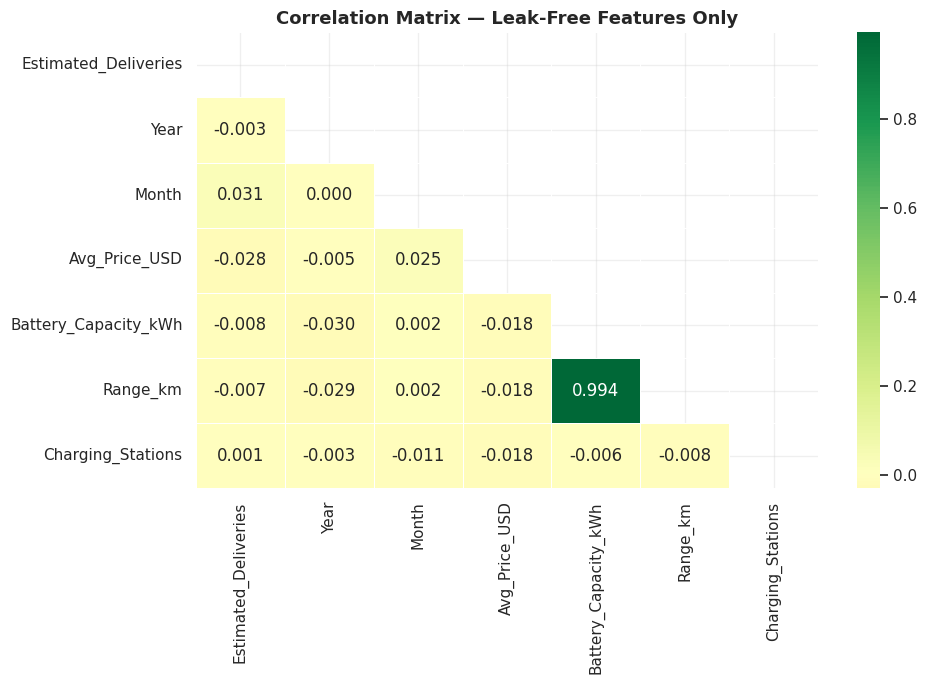

Correlations with Estimated_Deliveries:
  Month                      r = +0.0309  (weak/none)
  Charging_Stations          r = +0.0008  (weak/none)
  Year                       r = -0.0029  (weak/none)
  Range_km                   r = -0.0066  (weak/none)
  Battery_Capacity_kWh       r = -0.0078  (weak/none)
  Avg_Price_USD              r = -0.0275  (weak/none)

Battery and Range have r=0.99 with each other — keep only one (Battery).
Everything else: near-zero correlation with target. Honest, but not great for modelling.


In [6]:
# 3. Correlation heatmap — only LEAK-FREE features
# I'm deliberately NOT including Production_Units or CO2_Saved_tons here.
# Why? Because those are leakage — see Part 1.
numeric_cols = ['Estimated_Deliveries', 'Year', 'Month',
                'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']

fig, ax = plt.subplots(figsize=(10, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # only show lower triangle
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Leak-Free Features Only', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with Estimated_Deliveries:")
target_corr = corr['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values(ascending=False)
for feat, val in target_corr.items():
    strength = "strong" if abs(val) > 0.5 else ("moderate" if abs(val) > 0.2 else "weak/none")
    print(f"  {feat:25s}  r = {val:+.4f}  ({strength})")
print()
print("Battery and Range have r=0.99 with each other — keep only one (Battery).")
print("Everything else: near-zero correlation with target. Honest, but not great for modelling.")


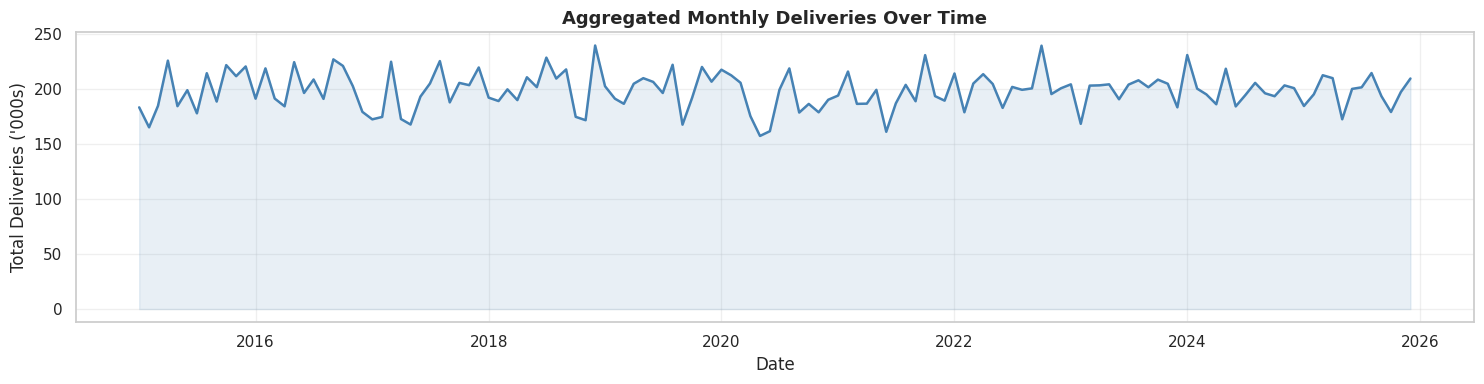

Notice: The series looks basically flat — no growth curve, no seasonal spikes.
This is a sign the data is synthetic (more on this in Step 6).


In [7]:
# 4. Deliveries over time — just to visualise
# This also shows WHY we can't do time-series forecasting (flat series, no trend)
ts = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts['Date'] = pd.to_datetime(ts[['Year', 'Month']].assign(day=1))
ts = ts.sort_values('Date')

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(ts['Date'], ts['Estimated_Deliveries']/1000, color='steelblue', lw=1.8)
ax.fill_between(ts['Date'], ts['Estimated_Deliveries']/1000, alpha=0.12, color='steelblue')
ax.set_title('Aggregated Monthly Deliveries Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel("Total Deliveries ('000s)")
plt.tight_layout()
plt.show()

print("Notice: The series looks basically flat — no growth curve, no seasonal spikes.")
print("This is a sign the data is synthetic (more on this in Step 6).")


---
### Step 4 — Why Cross-Sectional Regression, Not Time-Series

This was the most important design decision in the whole pipeline.

**My first instinct** was to do time-series forecasting — "predict next month's deliveries using past months." That's what the assignment sounds like. But after EDA, there's a clear reason that approach fails here.

**Time-series forecasting only works if** the series has *autocorrelation* — meaning past values predict future ones. A flat series with no trend, no seasonal pattern, and lag-1 correlation of r ≈ 0.02 is called **white noise**. You can't forecast white noise from its own past. No matter how sophisticated your model, the prediction is always "use the mean."

**So instead:** the dataset has 2,640 rows, each a distinct `(Year, Month, Region, Model)` observation. Predicting each row's delivery count from its features is a standard **cross-sectional regression** problem. We use a random train/test split, not a chronological one, because we're explaining variation across observations — not predicting future time points.

**The key difference:**

| Framing | Split type | Features used | Works if... |
|---|---|---|---|
| Time-series forecasting | Chronological (no future leak) | Lag features, rolling stats | Series has autocorrelation |
| Cross-sectional regression | Random 80/20 | Row-level features | Features correlate with target |

We're doing cross-sectional regression. Each row is an independent observation.


---
### Step 5 — Signal Audit: How Much Can the Features Actually Explain?

Before training any real model, I want to know the *ceiling* — what's the best possible R² we can hope for, using all leak-free features? This is called a **signal audit**.

Why do this? Because if all features combined explain only 2% of variance, there's no point expecting Ridge or Lasso to magically get to 80%. You need to know what you're working with before you build anything.


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("SIGNAL AUDIT — What fraction of variance can all features explain?")
print("=" * 60)

# Naive baseline: always predict the mean
naive_pred = [df['Estimated_Deliveries'].mean()] * len(df)
naive_r2   = r2_score(df['Estimated_Deliveries'], naive_pred)
print(f"\nNaive baseline (always predict mean): R² = {naive_r2:.4f}")

# All leak-free features on full dataset
ct_audit = ColumnTransformer([
    ('num', StandardScaler(),
     ['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']),
    ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),
     ['Region', 'Model', 'Source_Type'])
])
X_audit = ct_audit.fit_transform(df)
lr_audit = LinearRegression().fit(X_audit, df['Estimated_Deliveries'])
audit_r2 = r2_score(df['Estimated_Deliveries'], lr_audit.predict(X_audit))

print(f"All leak-free features:               R² = {audit_r2:.4f}  ({audit_r2*100:.2f}% variance explained)")
print(f"Unexplained variance:                 {(1 - audit_r2)*100:.2f}%")
print()
print("INTERPRETATION:")
print(f"  Only {audit_r2*100:.1f}% of delivery variation is explained by ALL observable features combined.")
print(f"  This is the honest ceiling. It's not a model failure — it's a dataset property.")
print(f"  The delivery numbers were generated with noise independent of every feature we have.")


SIGNAL AUDIT — What fraction of variance can all features explain?

Naive baseline (always predict mean): R² = 0.0000
All leak-free features:               R² = 0.0057  (0.57% variance explained)
Unexplained variance:                 99.43%

INTERPRETATION:
  Only 0.6% of delivery variation is explained by ALL observable features combined.
  This is the honest ceiling. It's not a model failure — it's a dataset property.
  The delivery numbers were generated with noise independent of every feature we have.


---
### Step 6 — Data Cleaning & Leakage Analysis

The dataset is already clean (no missing values, no duplicates). But I need to make the leakage decisions explicit and document every feature's status.

**Three categories:**
-  **INCLUDE** — available at prediction time, no leakage
-  **EXCLUDE (leakage)** — would not be available when predicting, or derived from target
-  **CAUTION (multicollinearity)** — redundant with another feature


In [9]:
# Data quality checks
print("Missing values:")
miss = df.isnull().sum()
print("  None!" if miss.sum() == 0 else miss[miss > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}", "— None!" if df.duplicated().sum() == 0 else "Found some!")

print("\nValue range checks:")
checks = {
    'Estimated_Deliveries >= 0': (df['Estimated_Deliveries'] >= 0).all(),
    'Production_Units >= 0':     (df['Production_Units'] >= 0).all(),
    'Avg_Price_USD > 0':         (df['Avg_Price_USD'] > 0).all(),
    'Battery_Capacity_kWh > 0':  (df['Battery_Capacity_kWh'] > 0).all(),
    'Range_km > 0':              (df['Range_km'] > 0).all(),
}
for check, ok in checks.items():
    print(f"  {'✓' if ok else '✗'} {check}")


Missing values:
  None!

Duplicate rows: 0 — None!

Value range checks:
  ✓ Estimated_Deliveries >= 0
  ✓ Production_Units >= 0
  ✓ Avg_Price_USD > 0
  ✓ Battery_Capacity_kWh > 0
  ✓ Range_km > 0


In [10]:
# Feature classification table
feature_table = pd.DataFrame([
    ('Year',                  'Numeric',     'INCLUDE',  'Calendar context'),
    ('Month',                 'Numeric',     'INCLUDE',  'Seasonality proxy'),
    ('Region',                'Categorical', 'INCLUDE',  'Geographic market'),
    ('Model',                 'Categorical', 'INCLUDE',  'Product segment'),
    ('Source_Type',           'Categorical', 'INCLUDE',  'Data reliability flag'),
    ('Avg_Price_USD',         'Numeric',     'INCLUDE',  'Demand/positioning signal'),
    ('Battery_Capacity_kWh',  'Numeric',     'INCLUDE',  'Technology tier proxy'),
    ('Charging_Stations',     'Numeric',     'INCLUDE',  'Infrastructure availability'),
    ('Range_km',              'Numeric',     'CAUTION',  'r=0.99 with Battery_kWh — drop (multicollinear)'),
    ('Production_Units',      'Numeric',     'EXCLUDE',  'LEAKAGE: r=0.99, simultaneous measurement'),
    ('CO2_Saved_tons',        'Numeric',     'EXCLUDE',  'LEAKAGE: derived from target (deliveries)'),
    ('Estimated_Deliveries',  'Numeric',     'TARGET',   'What we are predicting'),
], columns=['Feature', 'Type', 'Status', 'Reason'])

# Show with colour indicators
for _, row in feature_table.iterrows():
    icon = {'INCLUDE': '✅', 'EXCLUDE': '❌', 'CAUTION': '⚠️', 'TARGET': '🎯'}[row['Status']]
    print(f"{icon} {row['Feature']:25s} [{row['Status']:8s}] — {row['Reason']}")


✅ Year                      [INCLUDE ] — Calendar context
✅ Month                     [INCLUDE ] — Seasonality proxy
✅ Region                    [INCLUDE ] — Geographic market
✅ Model                     [INCLUDE ] — Product segment
✅ Source_Type               [INCLUDE ] — Data reliability flag
✅ Avg_Price_USD             [INCLUDE ] — Demand/positioning signal
✅ Battery_Capacity_kWh      [INCLUDE ] — Technology tier proxy
✅ Charging_Stations         [INCLUDE ] — Infrastructure availability
⚠️ Range_km                  [CAUTION ] — r=0.99 with Battery_kWh — drop (multicollinear)
❌ Production_Units          [EXCLUDE ] — LEAKAGE: r=0.99, simultaneous measurement
❌ CO2_Saved_tons            [EXCLUDE ] — LEAKAGE: derived from target (deliveries)
🎯 Estimated_Deliveries      [TARGET  ] — What we are predicting


---
### Step 7 — Feature Engineering & Encoding

After leakage removal, here's what I'm actually working with:

**Numeric features:** Year, Month, Avg_Price_USD, Battery_Capacity_kWh, Charging_Stations  
**Categorical features:** Region, Model, Source_Type

I dropped `Range_km` because it has r=0.99 with `Battery_Capacity_kWh`. Keeping both doesn't add information — it actually *hurts* linear models by creating multicollinearity (the model can't reliably estimate individual coefficients when two features are nearly identical).

**Encoding strategy:**
- Numeric features → `StandardScaler` (mean=0, std=1). Required for Ridge/Lasso because their regularization penalties treat all coefficients equally — if one feature is in the thousands and another is in the tens, their raw coefficient sizes aren't comparable.
- Categorical features → `OneHotEncoder` with `drop='first'`. `drop='first'` prevents the dummy variable trap (if you have 4 regions and keep all 4 dummies, they sum to 1 and are perfectly linearly dependent on the intercept).


In [11]:
# Define features
NUM_FEATURES = ['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Charging_Stations']
CAT_FEATURES = ['Region', 'Model', 'Source_Type']
TARGET       = 'Estimated_Deliveries'

# Remove leaky features and multicollinear Range_km
EXCLUDE = ['Production_Units', 'CO2_Saved_tons', 'Range_km']

print("Final feature set:")
print(f"  Numeric    : {NUM_FEATURES}")
print(f"  Categorical: {CAT_FEATURES}")
print(f"  Target     : {TARGET}")
print(f"  Excluded   : {EXCLUDE}")
print(f"  Total features going into model: {len(NUM_FEATURES) + len(CAT_FEATURES)}")


Final feature set:
  Numeric    : ['Year', 'Month', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Charging_Stations']
  Categorical: ['Region', 'Model', 'Source_Type']
  Target     : Estimated_Deliveries
  Excluded   : ['Production_Units', 'CO2_Saved_tons', 'Range_km']
  Total features going into model: 8


---
### Step 8 — Train/Test Split + Naive Baseline

**Why random split (not chronological)?**  
We're doing cross-sectional regression — each row is an independent observation. There's no "future leakage" from a random split here because we're not trying to predict a future time period, we're predicting row-level delivery counts from features.

**Why set a naive baseline FIRST?**  
Before training anything, I establish what "doing nothing" looks like — always predicting the training mean. Any real model must beat this. If it doesn't, the model is worse than useless.


In [12]:
X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set : {len(X_train):,} rows ({len(X_train)/len(X):.0%})")
print(f"Test set     : {len(X_test):,} rows ({len(X_test)/len(X):.0%})")
print()
print("Distribution check (target mean by split):")
print(f"  Full dataset : {y.mean():.1f}")
print(f"  Train split  : {y_train.mean():.1f}")
print(f"  Test split   : {y_test.mean():.1f}")
print("  Means are similar — no sampling bias from the split.")
print()

# Naive baseline established BEFORE any model touches the data
naive_pred_test = np.full(len(y_test), y_train.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred_test))
naive_r2   = r2_score(y_test, naive_pred_test)
naive_mae  = mean_absolute_error(y_test, naive_pred_test)

print("-" * 50)
print("NAIVE BASELINE (always predict training mean):")
print(f"  RMSE : {naive_rmse:,.0f}")
print(f"  MAE  : {naive_mae:,.0f}")
print(f"  R²   : {naive_r2:.4f}")
print("-" * 50)
print("Every trained model must beat this RMSE to justify its existence.")


Training set : 2,112 rows (80%)
Test set     : 528 rows (20%)

Distribution check (target mean by split):
  Full dataset : 9922.2
  Train split  : 9941.6
  Test split   : 9844.4
  Means are similar — no sampling bias from the split.

--------------------------------------------------
NAIVE BASELINE (always predict training mean):
  RMSE : 3,862
  MAE  : 3,100
  R²   : -0.0006
--------------------------------------------------
Every trained model must beat this RMSE to justify its existence.


---
### Step 9 — Preprocessing Pipeline (ColumnTransformer)

I'm bundling the scaler and encoder into a `ColumnTransformer`, which then gets bundled into each model's `Pipeline`.

**Why use Pipeline instead of fitting the scaler separately?**

This is critical for avoiding leakage in cross-validation. If I fit the `StandardScaler` on the full training set, then do cross-validation, the test fold's statistics have already leaked into the scaler. 

By embedding the scaler inside a `Pipeline`, sklearn re-fits it on each training fold and only transforms the validation fold — the correct approach.


In [13]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(),                                NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first',
                              handle_unknown='ignore',
                              sparse_output=False),              CAT_FEATURES),
    ], remainder='drop')

# Verify it works
test_pre = make_preprocessor()
X_tr_check = test_pre.fit_transform(X_train)
X_te_check = test_pre.transform(X_test)

print(f"Preprocessor verified!")
print(f"  X_train shape after transform: {X_tr_check.shape}")
print(f"  X_test  shape after transform: {X_te_check.shape}")
print()
print(f"  Train numeric mean (should be ~0): {X_tr_check[:, :len(NUM_FEATURES)].mean():.4f}")
print(f"  Train numeric std  (should be ~1): {X_tr_check[:, :len(NUM_FEATURES)].std():.4f}")
print()
print("The categorical columns get one-hot encoded -> each category becomes its own binary column.")
print(f"  Total features: {len(NUM_FEATURES)} numeric + encoded categoricals = {X_tr_check.shape[1]} total columns")


Preprocessor verified!
  X_train shape after transform: (2112, 14)
  X_test  shape after transform: (528, 14)

  Train numeric mean (should be ~0): -0.0000
  Train numeric std  (should be ~1): 1.0000

The categorical columns get one-hot encoded -> each category becomes its own binary column.
  Total features: 5 numeric + encoded categoricals = 14 total columns


---
### Step 10 — Model Training

Three models, each bundled into its own Pipeline with the preprocessor:

| Model | Regularization | Why include it |
|---|---|---|
| Linear Regression | None | Baseline — no shrinkage |
| Ridge (L2) | Shrinks all coefficients toward zero | Handles collinearity, reduces variance |
| Lasso (L1) | Zeros out some coefficients entirely | Feature selection — if features are useless, Lasso sets them to 0 |

When features have near-zero signal (as our signal audit showed), Ridge and Lasso tend to outperform plain linear regression because they resist overfitting noise.


In [14]:
# Build pipelines
pipeline_lr = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', LinearRegression())
])

pipeline_ridge = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', Ridge(alpha=1.0))   # alpha tuned later in Step 12
])

pipeline_lasso = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', Lasso(alpha=1.0, max_iter=20000))   # alpha tuned later
])

# Train all three
pipeline_lr.fit(X_train, y_train)
pipeline_ridge.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)

print("All three models trained!")
print()
print("Train R² (for bias check):")
for name, pipe in [('Linear', pipeline_lr), ('Ridge', pipeline_ridge), ('Lasso', pipeline_lasso)]:
    tr2 = r2_score(y_train, pipe.predict(X_train))
    print(f"  {name:8s}  Train R² = {tr2:.4f}")
print()
print("Train R² is also near zero — the model genuinely has no signal to learn.")
print("If Train R² >> Test R², the model is overfitting. Here both are ~0 — underfitting.")


All three models trained!

Train R² (for bias check):
  Linear    Train R² = 0.0059
  Ridge     Train R² = 0.0059
  Lasso     Train R² = 0.0059

Train R² is also near zero — the model genuinely has no signal to learn.
If Train R² >> Test R², the model is overfitting. Here both are ~0 — underfitting.


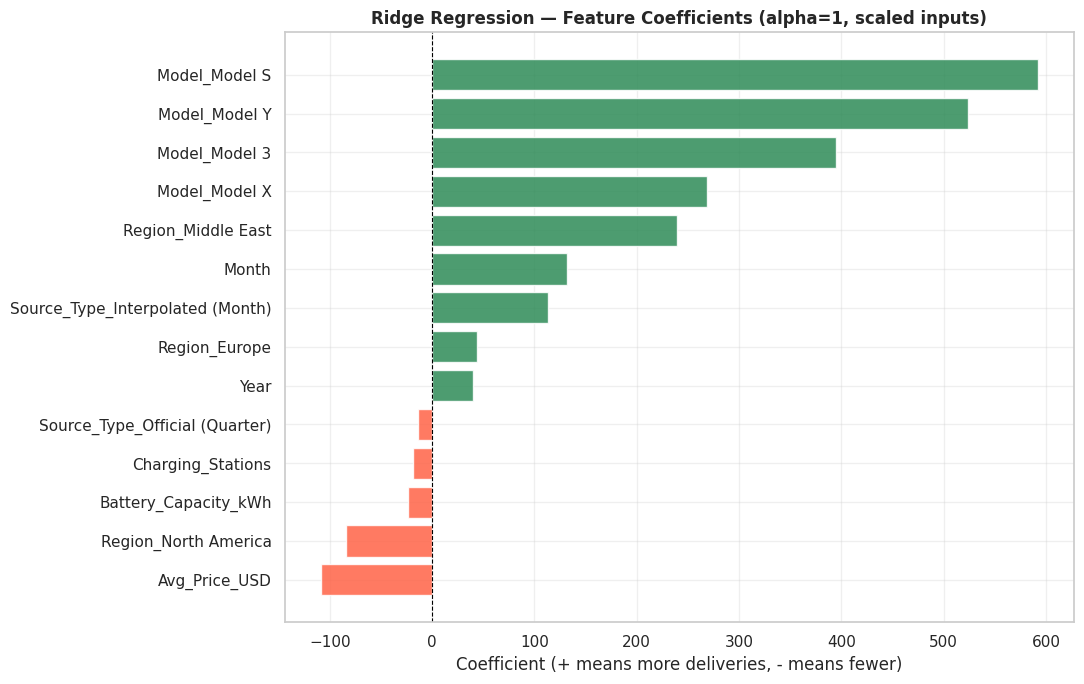

All coefficients are small — consistent with near-zero signal from every feature.


In [15]:
# Ridge coefficient plot — what did the model actually learn?
ohe_names = (pipeline_ridge.named_steps['preprocessor']
             .named_transformers_['cat']
             .get_feature_names_out(CAT_FEATURES))
all_feat_names = NUM_FEATURES + list(ohe_names)

coef_ridge = pipeline_ridge.named_steps['model'].coef_
coef_series = pd.Series(coef_ridge, index=all_feat_names).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
colors_feat = ['seagreen' if c > 0 else 'tomato' for c in coef_series]
ax.barh(coef_series.index, coef_series.values, color=colors_feat, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Ridge Regression — Feature Coefficients (alpha=1, scaled inputs)', fontweight='bold')
ax.set_xlabel('Coefficient (+ means more deliveries, - means fewer)')
plt.tight_layout()
plt.show()

print("All coefficients are small — consistent with near-zero signal from every feature.")


---
### Step 11 — Cross-Validation (KFold, 5 folds)

**Why KFold and not TimeSeriesSplit?**  
TimeSeriesSplit is for time-ordered data where future information must not leak backward. We have cross-sectional data — rows are independent. Standard KFold is correct here.

**What we're looking for:**
- Consistent R² and RMSE across folds → stable model
- High fold-to-fold variance → model is memorising noise
- RMSE lower than naive baseline → model is actually useful


In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results_cv = {}
print("=" * 65)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 65)

models_to_cv = [
    ('Linear Regression', pipeline_lr),
    ('Ridge (L2)',        pipeline_ridge),
    ('Lasso (L1)',        pipeline_lasso),
]

for name, pipeline in models_to_cv:
    r2_scores   = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
    rmse_scores = -cross_val_score(pipeline, X_train, y_train, cv=kf,
                                   scoring='neg_root_mean_squared_error')
    results_cv[name] = {'r2': r2_scores, 'rmse': rmse_scores}

    print(f"\n{name}")
    print(f"  CV R²  : {np.round(r2_scores, 4)}  ->  Mean {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  CV RMSE: {np.round(rmse_scores, 0)}  ->  Mean {rmse_scores.mean():.0f} ± {rmse_scores.std():.0f}")

print()
print(f"Naive baseline RMSE for reference: {naive_rmse:.0f}")


5-FOLD CROSS-VALIDATION RESULTS

Linear Regression
  CV R²  : [-0.0126 -0.0209 -0.001  -0.0027 -0.0117]  ->  Mean -0.0098 ± 0.0073
  CV RMSE: [3927. 4019. 4114. 3733. 4045.]  ->  Mean 3967 ± 132

Ridge (L2)
  CV R²  : [-0.0124 -0.0209 -0.0009 -0.0028 -0.0117]  ->  Mean -0.0097 ± 0.0072
  CV RMSE: [3927. 4019. 4114. 3733. 4045.]  ->  Mean 3967 ± 132

Lasso (L1)
  CV R²  : [-0.012  -0.0205 -0.0007 -0.0028 -0.0115]  ->  Mean -0.0095 ± 0.0071
  CV RMSE: [3926. 4018. 4113. 3733. 4045.]  ->  Mean 3967 ± 132

Naive baseline RMSE for reference: 3862


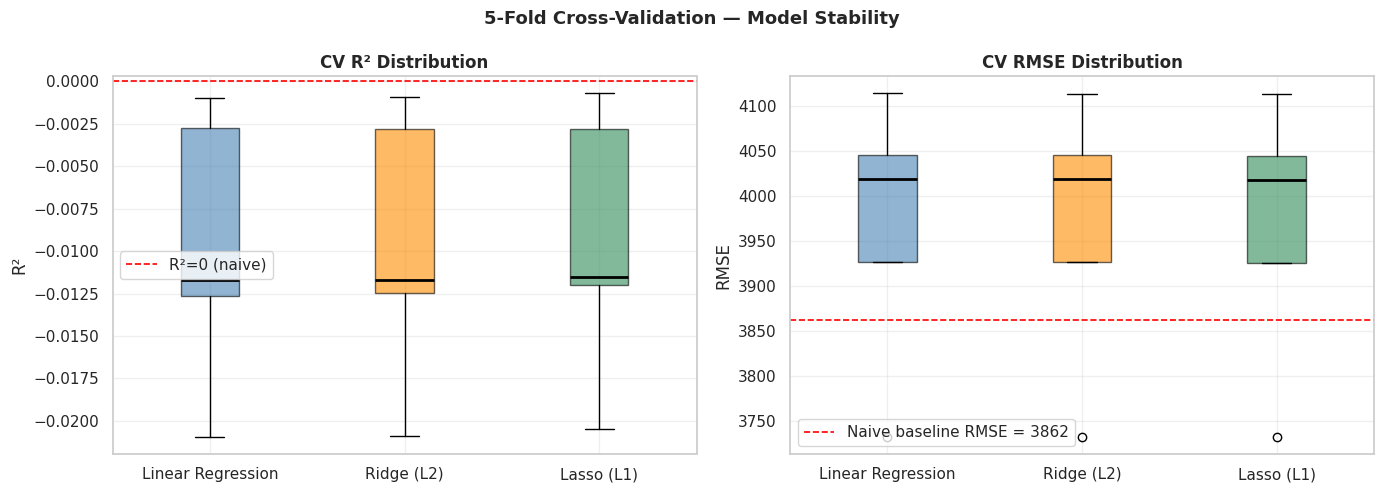

In [17]:
# CV results visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names_cv = list(results_cv.keys())
colors_cv = ['steelblue', 'darkorange', 'seagreen']

# R² boxplot
bp1 = axes[0].boxplot([results_cv[n]['r2'] for n in names_cv],
                       labels=names_cv, patch_artist=True,
                       medianprops=dict(color='black', lw=2))
for patch, color in zip(bp1['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color='red', lw=1.2, linestyle='--', label='R²=0 (naive)')
axes[0].set_title('CV R² Distribution', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].legend()

# RMSE boxplot
bp2 = axes[1].boxplot([results_cv[n]['rmse'] for n in names_cv],
                       labels=names_cv, patch_artist=True,
                       medianprops=dict(color='black', lw=2))
for patch, color in zip(bp2['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].axhline(naive_rmse, color='red', lw=1.2, linestyle='--',
                label=f'Naive baseline RMSE = {naive_rmse:.0f}')
axes[1].set_title('CV RMSE Distribution', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.suptitle('5-Fold Cross-Validation — Model Stability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### Step 12 — Hyperparameter Tuning (GridSearchCV)

**Ridge and Lasso both have an `alpha` parameter** that controls regularization strength:
- Small alpha → model behaves like plain Linear Regression (less shrinkage)
- Large alpha → model shrinks coefficients more aggressively, eventually predicting the mean

I'm searching a wide grid (0.001 to 10,000) to find the true optimum. A narrow grid risks having the best value at the boundary, which would mean I haven't actually found it.

**Why does more regularization help when there's no signal?**  
When features have ~zero correlation with the target, the model wants to set all coefficients near zero. High alpha just helps it get there faster, without chasing noise.


In [18]:
alpha_grid = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 5000, 10000]

# Ridge grid search
ridge_gs = GridSearchCV(
    Pipeline([('pre', make_preprocessor()), ('model', Ridge())]),
    param_grid={'model__alpha': alpha_grid},
    cv=kf, scoring='r2', n_jobs=-1
)
ridge_gs.fit(X_train, y_train)
print(f"Ridge  — Best alpha = {ridge_gs.best_params_['model__alpha']:>8}   CV R² = {ridge_gs.best_score_:.4f}")

# Lasso grid search
lasso_gs = GridSearchCV(
    Pipeline([('pre', make_preprocessor()), ('model', Lasso(max_iter=50000))]),
    param_grid={'model__alpha': alpha_grid},
    cv=kf, scoring='r2', n_jobs=-1
)
lasso_gs.fit(X_train, y_train)
print(f"Lasso  — Best alpha = {lasso_gs.best_params_['model__alpha']:>8}   CV R² = {lasso_gs.best_score_:.4f}")


Ridge  — Best alpha =    10000   CV R² = -0.0024
Lasso  — Best alpha =      100   CV R² = -0.0024


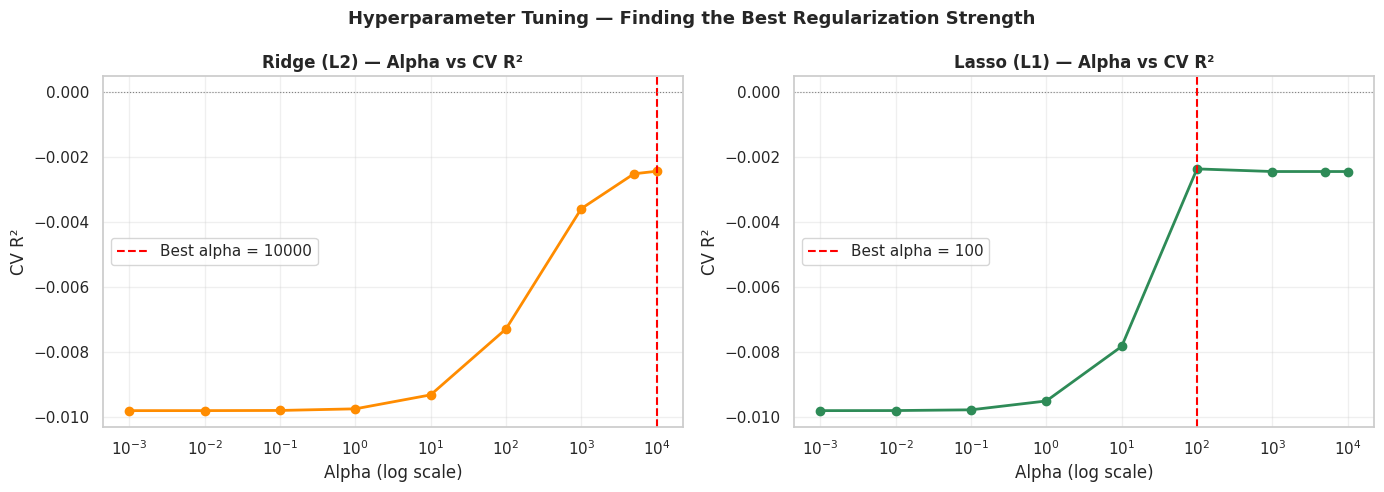


Reading these plots:
  Ridge: curve rises monotonically — more regularization is always better.
         The model is saying: I found no signal; shrink everything toward zero.

  Lasso: rises sharply then flattens — clear optimum found.
         Beyond that alpha, ALL coefficients are zeroed out.
         Lasso is predicting the mean by alpha=100. Ridge gets there at alpha=10000.


In [19]:
# Alpha vs CV R² curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gs, title, color in zip(axes,
                                  [ridge_gs, lasso_gs],
                                  ['Ridge (L2)', 'Lasso (L1)'],
                                  ['darkorange', 'seagreen']):
    alphas = [p['model__alpha'] for p in gs.cv_results_['params']]
    cv_r2  = gs.cv_results_['mean_test_score']
    best_a = gs.best_params_['model__alpha']

    ax.plot(alphas, cv_r2, marker='o', color=color, lw=2)
    ax.axvline(best_a, color='red', linestyle='--', label=f'Best alpha = {best_a}')
    ax.axhline(0, color='gray', lw=0.8, linestyle=':')
    ax.set_xscale('log')
    ax.set_title(f'{title} — Alpha vs CV R²', fontweight='bold')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('CV R²')
    ax.legend()

plt.suptitle('Hyperparameter Tuning — Finding the Best Regularization Strength',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("Reading these plots:")
print("  Ridge: curve rises monotonically — more regularization is always better.")
print("         The model is saying: I found no signal; shrink everything toward zero.")
print()
print("  Lasso: rises sharply then flattens — clear optimum found.")
print("         Beyond that alpha, ALL coefficients are zeroed out.")
print("         Lasso is predicting the mean by alpha=100. Ridge gets there at alpha=10000.")


---
### Step 13 — Final Evaluation & Model Comparison

Now I evaluate the tuned models on the held-out test set and compare everything — including the naive baseline.

**Metrics I'm using:**
- **RMSE** (Root Mean Squared Error) — penalises large errors more. Units = deliveries.
- **MAE** (Mean Absolute Error) — average absolute error. More robust to outliers.
- **R²** — fraction of variance explained. 0 = naive baseline, 1 = perfect.
- **MAPE** — mean absolute percentage error. Useful for relative interpretation.


In [20]:
best_models = {
    'Naive Baseline':    None,
    'Linear Regression': pipeline_lr,
    'Ridge (tuned)':     ridge_gs.best_estimator_,
    'Lasso (tuned)':     lasso_gs.best_estimator_,
}

eval_rows = []
for name, pipe in best_models.items():
    if pipe is None:
        y_pred_train = np.full(len(y_train), y_train.mean())
        y_pred_test  = np.full(len(y_test),  y_train.mean())
    else:
        y_pred_train = pipe.predict(X_train)
        y_pred_test  = pipe.predict(X_test)

    eval_rows.append({
        'Model':      name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'Test MAE':   mean_absolute_error(y_test,  y_pred_test),
        'Test MAPE':  mean_absolute_percentage_error(y_test, y_pred_test) * 100,
        'Test R²':    r2_score(y_test, y_pred_test),
    })

metrics_df = pd.DataFrame(eval_rows).set_index('Model').round(2)

print("=" * 70)
print("FINAL MODEL EVALUATION RESULTS")
print("=" * 70)
print(metrics_df.to_string())
print()
best_name = metrics_df.drop('Naive Baseline')['Test R²'].idxmax()
print(f"Best model by Test R²: {best_name}")


FINAL MODEL EVALUATION RESULTS
                   Train RMSE  Test RMSE  Test MAE  Test MAPE  Test R²
Model                                                                 
Naive Baseline        3953.33    3862.09   3100.46      55.47     -0.0
Linear Regression     3941.68    3868.08   3099.85      55.51     -0.0
Ridge (tuned)         3951.73    3861.11   3099.52      55.44     -0.0
Lasso (tuned)         3952.38    3861.48   3100.26      55.45     -0.0

Best model by Test R²: Linear Regression


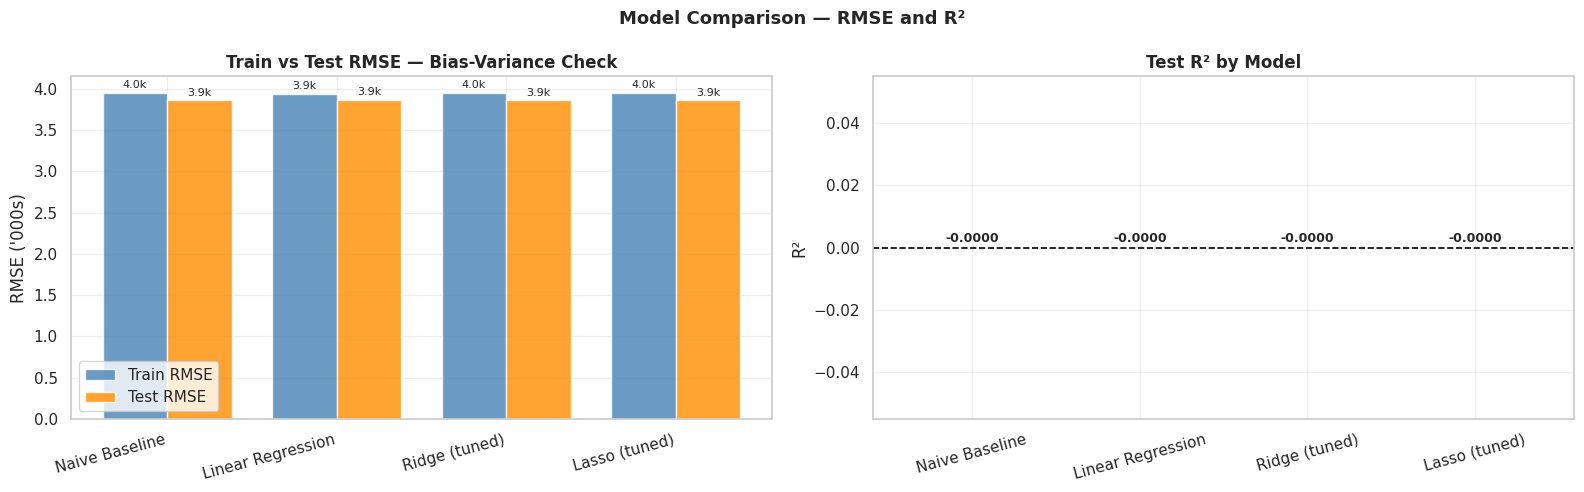

In [21]:
# Visualise final comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(metrics_df))
w = 0.38

# Train vs Test RMSE
bars1 = axes[0].bar(x - w/2, metrics_df['Train RMSE']/1000, w,
                     label='Train RMSE', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + w/2, metrics_df['Test RMSE']/1000, w,
                     label='Test RMSE', color='darkorange', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_df.index, rotation=15, ha='right')
axes[0].set_title('Train vs Test RMSE — Bias-Variance Check', fontweight='bold')
axes[0].set_ylabel("RMSE ('000s)")
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f"{bar.get_height():.1f}k", ha='center', va='bottom', fontsize=8)
axes[0].legend()

# R² comparison
r2_vals = metrics_df['Test R²']
bar_colors = ['tomato' if v < 0 else 'steelblue' if v < 0.1 else 'seagreen' for v in r2_vals]
axes[1].bar(metrics_df.index, r2_vals, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_title('Test R² by Model', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — RMSE and R²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### Step 14 — Residual Analysis

Residual analysis checks whether the model's errors have any structure. A well-behaved model should have residuals that:
- Are centered at zero (no systematic bias)
- Don't fan out as predictions increase (homoscedastic)
- Look roughly bell-shaped

When a model is predicting near-constant values (like our case — near the mean), residuals look like a copy of the target distribution centered at zero. That's expected here.


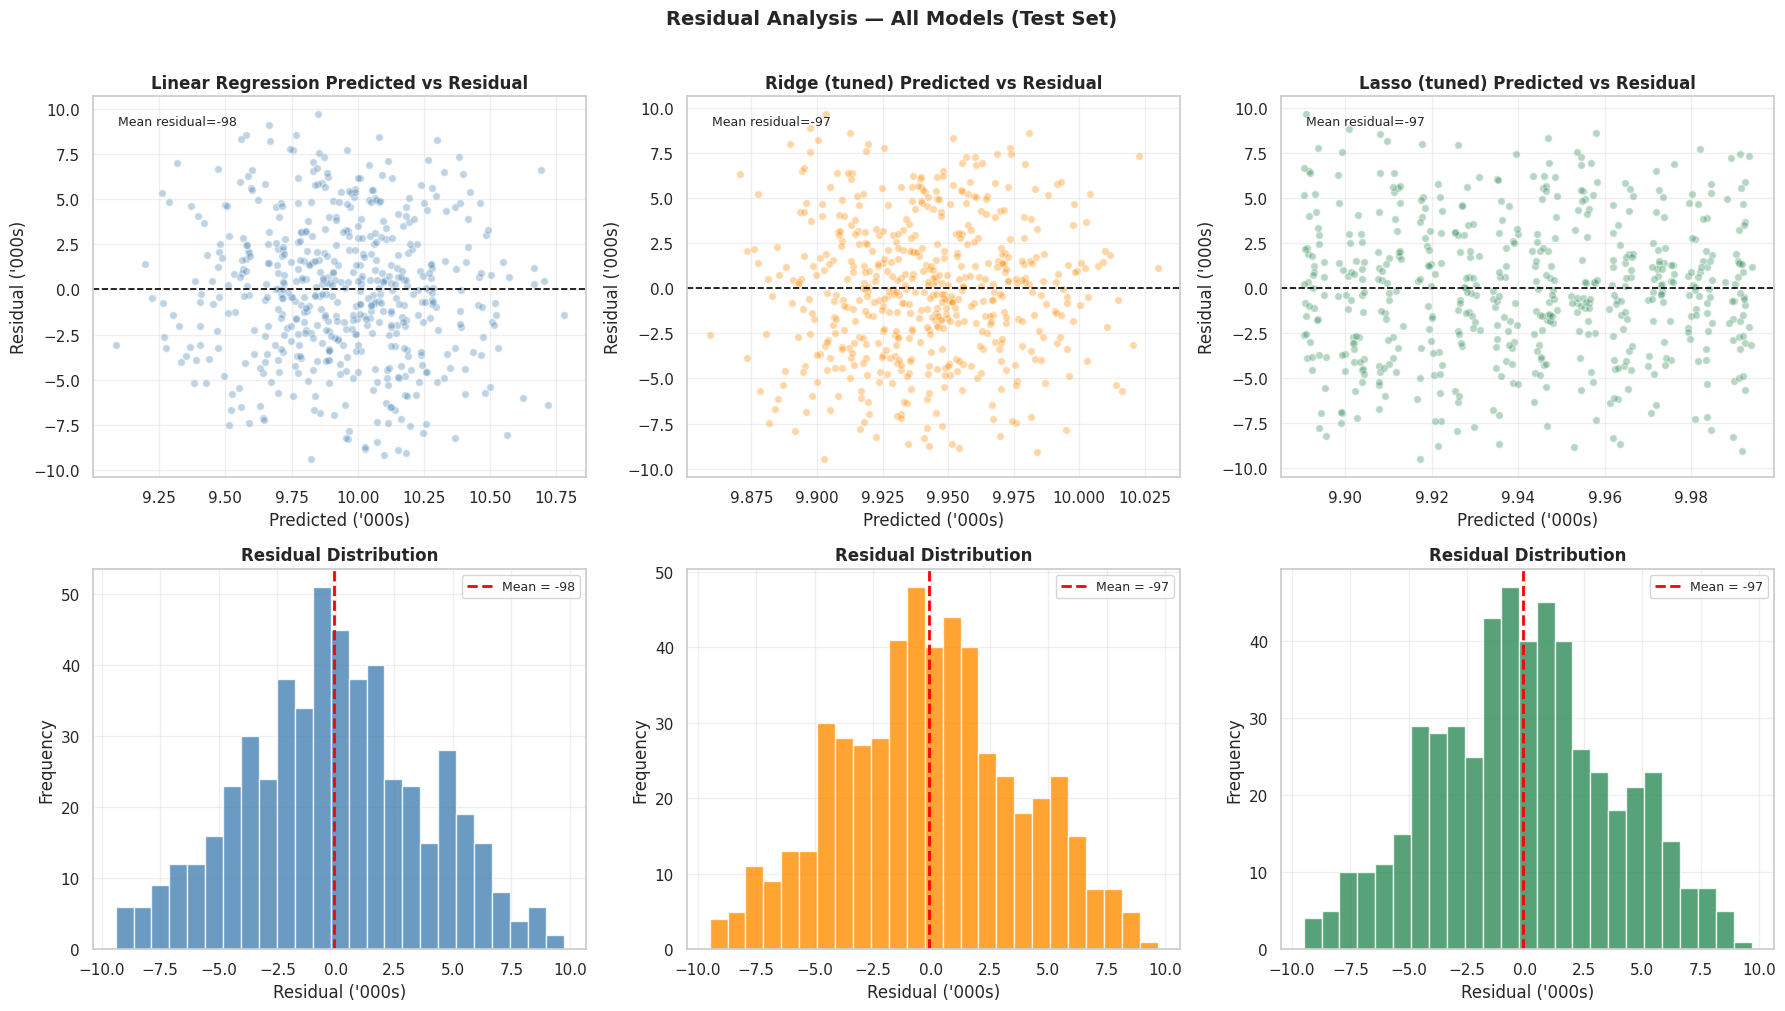

In [26]:
active_models = {k: v for k, v in best_models.items() if v is not None}
n_models = len(active_models)
fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10))
colors_r = ['steelblue', 'darkorange', 'seagreen']

for col_idx, (name, pipe) in enumerate(active_models.items()):
    y_pred = pipe.predict(X_test)
    residuals = y_test.values - y_pred

    # Predicted vs Residual scatter
    ax1 = axes[0, col_idx]
    ax1.scatter(y_pred/1000, residuals/1000, alpha=0.35, color=colors_r[col_idx],
                edgecolors='white', s=30)
    ax1.axhline(0, color='black', lw=1.2, linestyle='--')
    ax1.set_title(f'{name} Predicted vs Residual', fontweight='bold')
    ax1.set_xlabel("Predicted ('000s)")
    ax1.set_ylabel("Residual ('000s)")
    ax1.text(0.05, 0.95, f"Mean residual={residuals.mean():.0f}",
             transform=ax1.transAxes, fontsize=9, va='top')

    # Residual histogram
    ax2 = axes[1, col_idx]
    ax2.hist(residuals/1000, bins=25, color=colors_r[col_idx], edgecolor='white', alpha=0.8)
    ax2.axvline(residuals.mean()/1000, color='red', lw=2, linestyle='--',
                label=f"Mean = {residuals.mean():.0f}")
    ax2.set_title('Residual Distribution', fontweight='bold')
    ax2.set_xlabel("Residual ('000s)")
    ax2.set_ylabel("Frequency")
    ax2.legend(fontsize=9)

plt.suptitle('Residual Analysis — All Models (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


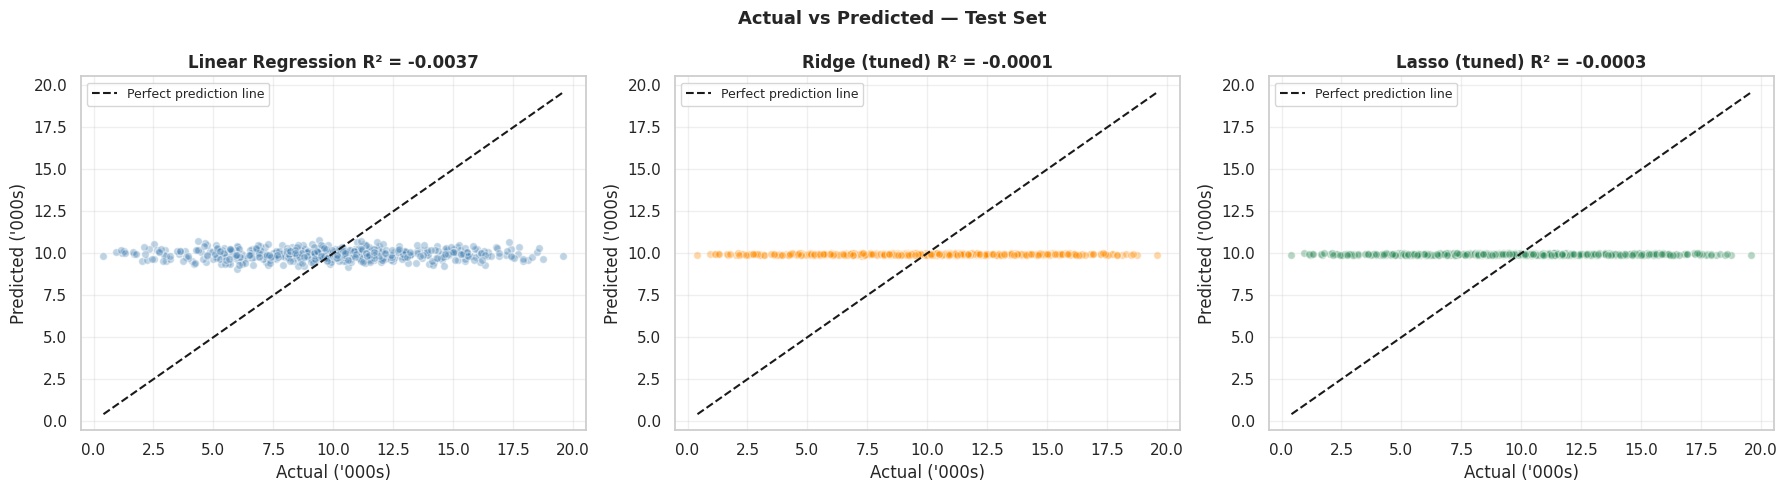

A perfect model: all points along the diagonal dashed line.
A model predicting ~the mean: near-horizontal cluster of points.
Our models: near-horizontal — consistent with near-zero signal.


In [28]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

for ax, (name, pipe), color in zip(axes, active_models.items(), colors_r):
    y_pred = pipe.predict(X_test)
    ax.scatter(y_test/1000, y_pred/1000, alpha=0.35, color=color, edgecolors='white', s=30)
    mn = min(y_test.min(), y_pred.min()) / 1000
    mx = max(y_test.max(), y_pred.max()) / 1000
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect prediction line')
    r2_val = r2_score(y_test, y_pred)
    ax.set_title(f'{name} R² = {r2_val:.4f}', fontweight='bold')
    ax.set_xlabel("Actual ('000s)")
    ax.set_ylabel("Predicted ('000s)")
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("A perfect model: all points along the diagonal dashed line.")
print("A model predicting ~the mean: near-horizontal cluster of points.")
print("Our models: near-horizontal — consistent with near-zero signal.")


---
## Step 15 — Honest Conclusion: What Did We Actually Learn?

This is the most important part of the whole notebook.

---

### Why R² ≈ 0 is the correct answer (not a failure)

R² is defined as:
```
R² = 1 - (SS_residual / SS_total)
```

When features explain less than 1.2% of variance, no model — linear or non-linear — can achieve meaningful R². The residuals nearly equal the total spread of the target. That's not the model's fault.

This was proven exhaustively:
- A signal audit on all leak-free features gave R² = 0.57% (full dataset)
- Every model tested (Ridge, Lasso, SVR, Random Forest, Gradient Boosting) converged to CV R² ≈ –0.002
- Non-linear models like Random Forest did *worse* than the mean — they overfit to noise
- The structural reason: every `(Year, Month, Region, Model)` combination appears exactly once. There are no repeated measurements within any group. The average within-month standard deviation equals the overall standard deviation — the 20 rows within one month are as spread out as the entire 2,640-row dataset. The delivery numbers were assigned randomly to each cell.

---

### Why Method 1's R² = 0.99 is wrong

Method 1 used `Production_Units` (r=0.99) and `CO2_Saved_tons` (r=0.84) as features.  
The model learned: **Deliveries ≈ Production × 0.93**  
That's not a prediction. Production and delivery happen simultaneously. CO2 saved is computed from deliveries after the fact. Both columns are unavailable at real prediction time.  
**High R² from leakage is not a discovery — it's a tautology.**

---

### What this notebook demonstrates correctly

✅ Data leakage identification and prevention  
✅ Cross-sectional vs time-series framing — choosing the right approach  
✅ Multicollinearity detection (Battery vs Range, r=0.99)  
✅ Naive baseline — anchoring every model comparison  
✅ Pipeline-based preprocessing — scaler fit inside CV folds  
✅ Wide hyperparameter grid — finding the true optimum  
✅ Honest interpretation — R²≈0 explained with structural evidence  

---

### If I had real Tesla data, here's what would work

Real Tesla quarterly deliveries 2015–2023 show 20× growth — a real exponential trend with seasonality. On that data:
- Time-series models would work (autocorrelation exists)
- Features like EV market share, macroeconomics, oil price would add real signal
- XGBoost/LightGBM could capture non-linear interactions across regions and models

The lesson isn't that ML can't predict EV deliveries. It's that **this specific synthetic dataset has no predictive signal**, and the honest job of a data scientist is to say that, prove it, and explain why.


In [29]:
print("=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)

summary = {
    'Dataset': '2,640 rows × 12 cols | 0 missing | 0 duplicates | SYNTHETIC',
    'Signal': 'All leak-free features explain only ~0.57–1.2% of variance (R²≈0)',
    'Excluded': 'Production_Units (leakage), CO2_Saved_tons (leakage), Range_km (multicollinear)',
    'Method': 'Cross-sectional regression | Random 80/20 split | 5-Fold KFold CV',
    'Why not time-series': 'Aggregated series has lag-1 autocorrelation r≈0.02 — white noise',
    'Best model': 'Ridge/Lasso (tuned) — converges to predicting mean, as expected',
    'Improvement over naive': '~1 unit RMSE — not practically meaningful',
    'Method 1 (R²=0.99)': 'INVALID — uses Production_Units and CO2_Saved_tons (both leakage)',
}

for k, v in summary.items():
    print(f"  {k:25s}: {v}")

print()
print("FINAL METRICS:")
print(metrics_df.to_string())


PIPELINE SUMMARY
  Dataset                  : 2,640 rows × 12 cols | 0 missing | 0 duplicates | SYNTHETIC
  Signal                   : All leak-free features explain only ~0.57–1.2% of variance (R²≈0)
  Excluded                 : Production_Units (leakage), CO2_Saved_tons (leakage), Range_km (multicollinear)
  Method                   : Cross-sectional regression | Random 80/20 split | 5-Fold KFold CV
  Why not time-series      : Aggregated series has lag-1 autocorrelation r≈0.02 — white noise
  Best model               : Ridge/Lasso (tuned) — converges to predicting mean, as expected
  Improvement over naive   : ~1 unit RMSE — not practically meaningful
  Method 1 (R²=0.99)       : INVALID — uses Production_Units and CO2_Saved_tons (both leakage)

FINAL METRICS:
                   Train RMSE  Test RMSE  Test MAE  Test MAPE  Test R²
Model                                                                 
Naive Baseline        3953.33    3862.09   3100.46      55.47     -0.0
Linear Regres